In [2]:
# EmporiUm Sales Territory Analysis
# Capstone 2 — Hamzah Alssoudi
# Territories: Maryland (Shruti Reddy) and Massachusetts (Bo Heap), both Northeast
# Data covers January 2022 through December 2025

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# Make output easier to read
pd.set_option('display.max_columns', None)
plt.rcParams['figure.figsize'] = (11, 6)

In [4]:
# Load the main transaction data (the "fact" table)
sales = pd.read_csv('StoreSales.csv')

# Load the store info (city, state, manager, region)
stores = pd.read_csv('StoreDetail.csv')

# Load the product info (product number, category IDs)
products = pd.read_csv('Products.csv')

# Load the category lookup (turns category IDs into readable names)
categories = pd.read_csv('ProductCategories.csv')

# Load the rewards customer list — NOTE: this file uses | as separator, not commas
customers = pd.read_csv('customer_list.csv', sep='|')

# Strip extra spaces from customer column names (one column has a trailing space)
customers.columns = customers.columns.str.strip()

print("Sales:", len(sales), "transactions")
print("Stores:", len(stores))
print("Products:", len(products))
print("Categories:", len(categories))
print("Customers:", len(customers))

Sales: 335129 transactions
Stores: 111
Products: 669
Categories: 52
Customers: 521


In [5]:
sales.info()

<class 'pandas.DataFrame'>
RangeIndex: 335129 entries, 0 to 335128
Data columns (total 5 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Transaction Date  335129 non-null  str    
 1   Store ID          335129 non-null  int64  
 2   RewardsID         34943 non-null   float64
 3   Prod Num          335129 non-null  str    
 4   Sale Amount       335129 non-null  float64
dtypes: float64(2), int64(1), str(2)
memory usage: 12.8 MB


In [6]:
stores.info()

<class 'pandas.DataFrame'>
RangeIndex: 111 entries, 0 to 110
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   Store Location     111 non-null    str  
 1   State              111 non-null    str  
 2   Store ID           111 non-null    int64
 3   Territory Manager  111 non-null    str  
 4   Region             111 non-null    str  
 5   Region Director    111 non-null    str  
dtypes: int64(1), str(5)
memory usage: 5.3 KB


In [7]:
products.info()

<class 'pandas.DataFrame'>
RangeIndex: 669 entries, 0 to 668
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   Prod Num       669 non-null    str  
 1   Product        669 non-null    str  
 2   CategoryID     669 non-null    int64
 3   SubcategoryID  669 non-null    str  
dtypes: int64(1), str(3)
memory usage: 21.0 KB


In [8]:
categories.info()

<class 'pandas.DataFrame'>
RangeIndex: 52 entries, 0 to 51
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   CategoryID     52 non-null     int64
 1   Category       52 non-null     str  
 2   SubcategoryID  52 non-null     str  
 3   Subcategory    52 non-null     str  
dtypes: int64(1), str(3)
memory usage: 1.8 KB


In [9]:
customers.info()

<class 'pandas.DataFrame'>
RangeIndex: 521 entries, 0 to 520
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   cust_id      521 non-null    int64
 1   date         521 non-null    str  
 2   time         521 non-null    str  
 3   name         521 non-null    str  
 4   email        521 non-null    str  
 5   phone        520 non-null    str  
 6   sms-opt-out  520 non-null    str  
dtypes: int64(1), str(6)
memory usage: 28.6 KB


In [10]:
sales.head()

,Transaction Date,Store ID,RewardsID,Prod Num,Sale Amount
0,1/1/2022,702,NaN,105349-M,8.00
1,1/1/2022,704,NaN,105350-T,144.00
2,1/1/2022,705,NaN,105351-M,44.00
3,1/1/2022,705,NaN,105352-M,47.61
4,1/1/2022,705,NaN,105353-A,20.36


In [13]:
# Data Cleaning and Preparation
# 1. Parse transaction dates so we can group by month and year
# 2. Add Month and Year columns for grouping
# 3. Fix a duplicate category key: 115-pai is listed twice, would duplicate paint sales on merge
# 4. Merge the tables so every transaction has city, state, manager, region, category
# 5. Handle 5 orphan products: valid Category ID but invalid Subcategory ID, label them manually

In [14]:
# 1. Convert text dates into real datetime objects
sales['Transaction Date'] = pd.to_datetime(sales['Transaction Date'], format='%m/%d/%Y')

# 2. Add Month and Year columns derived from the date
sales['Month'] = sales['Transaction Date'].dt.to_period('M')
sales['Year'] = sales['Transaction Date'].dt.year

# 3. Fix the duplicate '115-pai' subcategory before merging
categories.loc[categories['SubcategoryID'] == '115-pai', 'Subcategory'] = 'Paints & Brushes'
categories = categories.drop_duplicates(['CategoryID', 'SubcategoryID']).reset_index(drop=True)

# 4. Merge everything into one big table
df = sales.merge(stores, on='Store ID', how='left')
df = df.merge(products, on='Prod Num', how='left')
df = df.merge(categories, on=['CategoryID', 'SubcategoryID'], how='left')

# 5. Fix the 5 orphan adhesive products
orphan_mask = df['Category'].isna()
print("Transactions with no category match before fix:", orphan_mask.sum())
df.loc[orphan_mask, 'Category'] = 'Art Supplies'
df.loc[orphan_mask, 'Subcategory'] = 'Adhesives'
print("Transactions with no category match after fix:", df['Category'].isna().sum())

print("\nMerged table:", len(df), "transactions with", len(df.columns), "columns")

Transactions with no category match before fix: 3350
Transactions with no category match after fix: 0

Merged table: 335129 transactions with 17 columns


In [15]:
# Filter the merged data to only my assigned territories
MY_STATES = ['Maryland', 'Massachusetts']
terr = df[df['State'].isin(MY_STATES)].copy()

print("Maryland + Massachusetts transactions:", len(terr))
print(terr.groupby('State').size())

Maryland + Massachusetts transactions: 131476
State
Maryland         89466
Massachusetts    42010
dtype: int64


In [16]:
# Q1: Who are the territory managers? What are the store IDs and cities in each territory?

territory_overview = (stores[stores['State'].isin(MY_STATES)]
                      .sort_values(['State', 'Store ID'])
                      [['State', 'Territory Manager', 'Store ID', 'Store Location']]
                      .reset_index(drop=True))
territory_overview

,State,Territory Manager,Store ID,Store Location
0,Maryland,Shruti Reddy,731,Annapolis
1,Maryland,Shruti Reddy,732,Back River
2,Maryland,Shruti Reddy,733,Baltimore
3,Maryland,Shruti Reddy,734,Germantown
4,Maryland,Shruti Reddy,735,Howard
5,Maryland,Shruti Reddy,736,North Harford
6,Maryland,Shruti Reddy,737,Parkville
7,Maryland,Shruti Reddy,738,Queen Anne's County
8,Maryland,Shruti Reddy,739,Ridgely
9,Massachusetts,Bo Heap,730,Boston


In [17]:
# Compact summary: manager and store count per territory
for state in MY_STATES:
    sub = stores[stores['State'] == state]
    mgr = sub['Territory Manager'].iloc[0]
    cities = ', '.join(sub['Store Location'].tolist())
    print(f"{state}: manager = {mgr} | {len(sub)} stores")
    print(f"   Cities: {cities}\n")

Maryland: manager = Shruti Reddy | 9 stores
   Cities: Annapolis, Back River, Baltimore, Germantown, Howard, North Harford, Parkville, Queen Anne's County, Ridgely

Massachusetts: manager = Bo Heap | 18 stores
   Cities: Boston, Attleboro, Falmouth, Framingham, Haverhill, Hingham, Holyoke, Leominster, Lowell, Lynn, Nantucket, New Bedford, Northampton, Pittsfield, Provincetown, Quincy, Somerville, Worcester



In [18]:
# Finding: Maryland has 9 stores under Shruti Reddy. Massachusetts has 18 stores under Bo Heap.
# Massachusetts has twice as many stores, so raw revenue totals will favor it by default.
# I'll look at both total AND per-store revenue throughout to keep the comparison fair.

In [19]:
# Q2: What is monthly total revenue for in-store sales in each territory over the full period?

monthly_rev = (terr.groupby(['State', 'Month'])['Sale Amount']
               .sum()
               .unstack('State'))
monthly_rev.index = monthly_rev.index.astype(str)
monthly_rev.head(12)

State,Maryland,Massachusetts
Month,,
2022-01,190064.90,69396.42
2022-02,197529.18,65616.00
2022-03,210228.48,77390.00
2022-04,179004.18,81333.60
2022-05,212028.70,75919.64
2022-06,198318.98,81227.82
2022-07,231208.13,67271.23
2022-08,203503.40,73543.48
2022-09,158952.74,58716.74


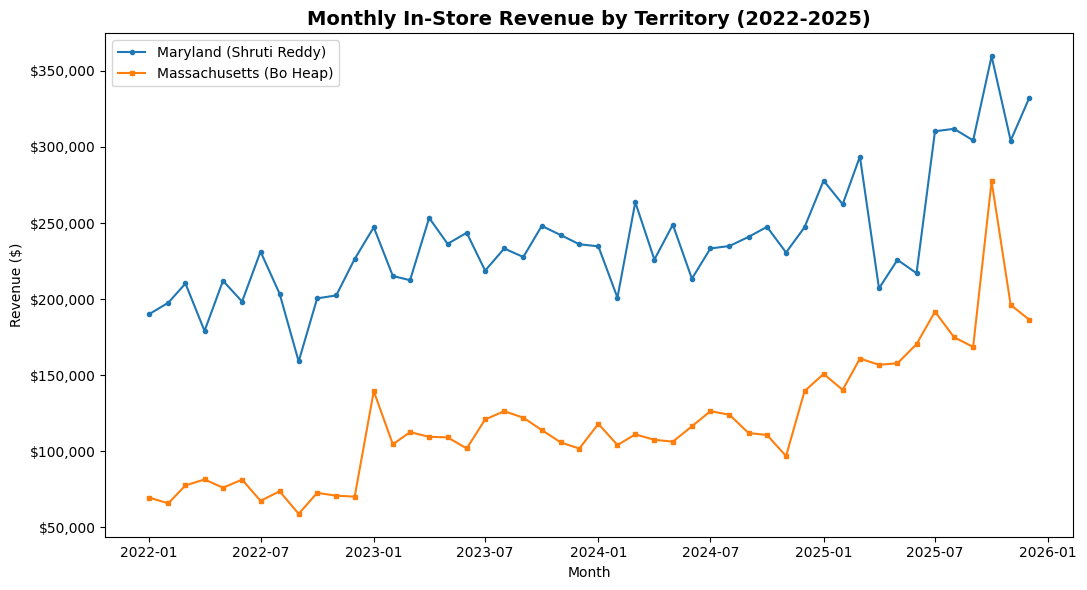

In [20]:
# Chart 1: Monthly revenue trend for both territories
fig, ax = plt.subplots()
x = pd.PeriodIndex(monthly_rev.index, freq='M').to_timestamp()
ax.plot(x, monthly_rev['Maryland'], marker='o', markersize=3, label='Maryland (Shruti Reddy)')
ax.plot(x, monthly_rev['Massachusetts'], marker='s', markersize=3, label='Massachusetts (Bo Heap)')
ax.set_title('Monthly In-Store Revenue by Territory (2022-2025)', fontsize=14, fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('Revenue ($)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'${v:,.0f}'))
ax.legend()
plt.tight_layout()
plt.show()

In [21]:
# Finding: Maryland runs consistently ABOVE Massachusetts in monthly revenue, and the
# gap grows over time. Both show recurring seasonal peaks typical of a student bookstore
# (back-to-school periods). I used a line chart because revenue over time is a trend,
# and lines make it easy to see seasonality and the gap between territories.

In [22]:
# Q3: How would you rank the sales performance of each store? Top-performing stores?

store_rev = (terr.groupby(['State', 'Store Location'])
             .agg(Total_Revenue=('Sale Amount', 'sum'),
                  Transactions=('Sale Amount', 'count'),
                  Avg_Transaction=('Sale Amount', 'mean'))
             .sort_values('Total_Revenue', ascending=False)
             .round(2))
store_rev

Total_Revenue  Transactions  \
State         Store Location                                     
Maryland      North Harford           8708119.00         69530   
Massachusetts Worcester                602183.44          4477   
Maryland      Germantown               584675.92          4363   
Massachusetts Leominster               338009.10          2293   
              Nantucket                335547.81          2272   
              Provincetown             328860.51          2310   
              Northampton              322039.24          2258   
              Holyoke                  320516.53          2168   
Maryland      Parkville                320441.24          2192   
              Howard                   319394.58          2181   
              Ridgely                  318511.04          2341   
Massachusetts Somerville               312873.59          2174   
Maryland      Baltimore                310099.90          2222   
Massachusetts Haverhill                305762.60          2287   
Maryland      Back River               303433.61          2228   
Massachusetts Lynn                     302049.65          2118   
              Pittsfield               301281.50          2172   
Maryland      Queen Anne's County      298074.49          2202   
Massachusetts New Bedford              295443.42          2203   
              Boston                   295201.29          2157   
              Attleboro                290883.71          2245   
              Hingham                  289633.52          2110   
Maryland      Annapolis                288865.31          2207   
Massachusetts Quincy                   279646.07          2192   
              Falmouth                 276965.55          2202   
              Framingham               269375.91          2172   
              Lowell                   266982.83          2200   

                                   Avg_Transaction  
State         Store Location                        
Maryland      North Harford                 125.24  
Massachusetts Worcester                     134.51  
Maryland      Germantown                    134.01  
Massachusetts Leominster                    147.41  
              Nantucket                     147.69  
              Provincetown                  142.36  
              Northampton                   142.62  
              Holyoke                       147.84  
Maryland      Parkville                     146.19  
              Howard                        146.44  
              Ridgely                       136.06  
Massachusetts Somerville                    143.92  
Maryland      Baltimore                     139.56  
Massachusetts Haverhill                     133.70  
Maryland      Back River                    136.19  
Massachusetts Lynn                          142.61  
              Pittsfield                    138.71  
Maryland      Queen Anne's County           135.37  
Massachusetts New Bedford                   134.11  
              Boston                        136.86  
              Attleboro                     129.57  
              Hingham                       137.27  
Maryland      Annapolis                     130.89  
Massachusetts Quincy                        127.58  
              Falmouth                      125.78  
              Framingham                    124.02  
              Lowell                        121.36

In [23]:
# Top 3 stores within each territory
for state in MY_STATES:
    print(f"--- Top 3 stores in {state} ---")
    top = store_rev.loc[state].sort_values('Total_Revenue', ascending=False).head(3)
    print(top[['Total_Revenue', 'Transactions']].to_string())
    print()

--- Top 3 stores in Maryland ---
                Total_Revenue  Transactions
Store Location                             
North Harford      8708119.00         69530
Germantown          584675.92          4363
Parkville           320441.24          2192

--- Top 3 stores in Massachusetts ---
                Total_Revenue  Transactions
Store Location                             
Worcester           602183.44          4477
Leominster          338009.10          2293
Nantucket           335547.81          2272



In [24]:
# Finding: North Harford alone generates ~$8.8M, more than ALL of Massachusetts combined.
# This single store accounts for most of Maryland's total revenue. Massachusetts revenue is
# more evenly spread across its 18 stores (Worcester, Leominster, Nantucket lead but none
# dominates). This concentration is important: Maryland's headline numbers depend heavily
# on one location, so per-store views give a truer picture of underlying demand.

In [25]:
# Q4: Who were the top customers in each territory?
# Compare RewardsID from sales to cust_id from customer list.

# Keep only rewards transactions in my territories, then join to customer names
terr_rewards = terr[terr['RewardsID'].notna()].copy()
terr_rewards['RewardsID'] = terr_rewards['RewardsID'].astype(int)

terr_named = terr_rewards.merge(
    customers[['cust_id', 'name']],
    left_on='RewardsID', right_on='cust_id', how='left')

print("Rewards transactions in my territories:", len(terr_named))

Rewards transactions in my territories: 13659


In [26]:
# Top 5 customers by total spend within each territory
for state in MY_STATES:
    print(f"--- Top 5 customers in {state} ---")
    top_cust = (terr_named[terr_named['State'] == state]
                .groupby(['RewardsID', 'name'])['Sale Amount']
                .agg(Total_Spend='sum', Transactions='count')
                .sort_values('Total_Spend', ascending=False)
                .head(5).round(2))
    print(top_cust.to_string())
    print()

--- Top 5 customers in Maryland ---
                          Total_Spend  Transactions
RewardsID name                                     
180       Cole Brown          7602.28            26
355       Donna Hayward       7081.17            24
467       Avon Barksdale      6172.68            27
99        Trent Lane          6076.89            22
75        Magnitude           5916.81            20

--- Top 5 customers in Massachusetts ---
                           Total_Spend  Transactions
RewardsID name                                      
292       Beverly Crusher      4758.92            14
384       Tracy Jordan         4197.55            14
47        Stanley H.           3979.73            12
3         Monica Geller        3966.91            15
188       Mellie Grant         3948.41            10



In [28]:
# Finding: These are the highest-spending rewards members in each territory. They're the
# natural audience for loyalty offers and re-engagement campaigns since they already
# account for a large share of identifiable spend. Keep in mind this only reflects the
# ~10% of transactions linked to a rewards account, there's opportunity to grow rewards
# enrollment to better identify our top spenders.

In [29]:
# Q5: Number of transactions per month by category, and total revenue per month by category.

# Category-level summary per territory: transactions, revenue, avg per transaction
cat_txn = (terr.groupby(['State', 'Category'])
           .agg(Transactions=('Sale Amount', 'count'),
                Total_Revenue=('Sale Amount', 'sum'))
           .round(2))
cat_txn['Avg_Transaction'] = (cat_txn['Total_Revenue'] / cat_txn['Transactions']).round(2)
cat_txn.sort_values(['State', 'Total_Revenue'], ascending=[True, False])

Transactions  Total_Revenue  \
State         Category                                                
Maryland      Technology & Accessories         16836     7826937.84   
              Textbooks                        11639     2021177.87   
              Apparel and Merchandise          15547      500587.47   
              Books (General)                  15335      494845.76   
              Art Supplies                     13454      433996.67   
              Stationery and Supplies          16655      174069.48   
Massachusetts Technology & Accessories          8724     4059863.21   
              Textbooks                         5789      998901.78   
              Apparel and Merchandise           8314      266531.69   
              Art Supplies                      6755      217215.46   
              Books (General)                   3409       99532.89   
              Stationery and Supplies           9019       91211.24   

                                        Avg_Transaction  
State         Category                                   
Maryland      Technology & Accessories           464.89  
              Textbooks                          173.66  
              Apparel and Merchandise             32.20  
              Books (General)                     32.27  
              Art Supplies                        32.26  
              Stationery and Supplies             10.45  
Massachusetts Technology & Accessories           465.37  
              Textbooks                          172.55  
              Apparel and Merchandise             32.06  
              Art Supplies                        32.16  
              Books (General)                     29.20  
              Stationery and Supplies             10.11

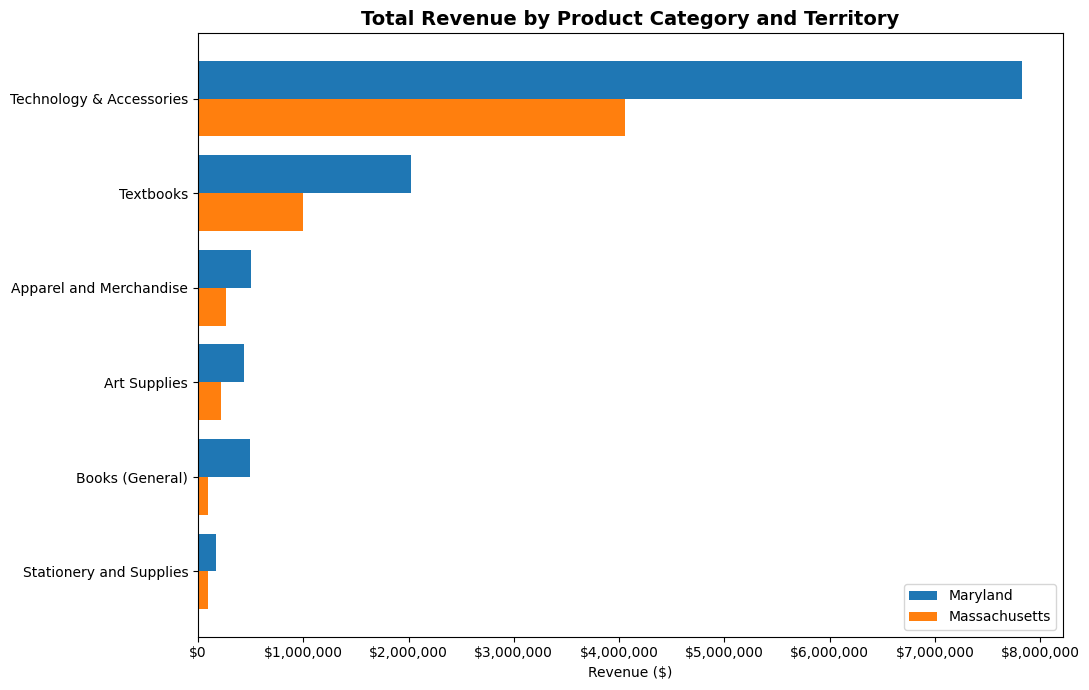

In [30]:
# Chart 2: Category revenue comparison between the two territories
cat_rev = (terr.groupby(['State', 'Category'])['Sale Amount'].sum()
           .unstack('State').fillna(0).sort_values('Massachusetts', ascending=True))

fig, ax = plt.subplots(figsize=(11, 7))
ypos = np.arange(len(cat_rev))
h = 0.4
ax.barh(ypos + h/2, cat_rev['Maryland'], height=h, label='Maryland')
ax.barh(ypos - h/2, cat_rev['Massachusetts'], height=h, label='Massachusetts')
ax.set_yticks(ypos)
ax.set_yticklabels(cat_rev.index)
ax.set_title('Total Revenue by Product Category and Territory', fontsize=14, fontweight='bold')
ax.set_xlabel('Revenue ($)')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'${v:,.0f}'))
ax.legend()
plt.tight_layout()
plt.show()


In [31]:
# Monthly revenue by category — useful for spotting seasonal patterns
monthly_cat = (terr.groupby(['Month', 'Category'])['Sale Amount'].sum()
               .unstack('Category').fillna(0).round(0))
monthly_cat.index = monthly_cat.index.astype(str)
monthly_cat.tail(6)

Category,Apparel and Merchandise,Art Supplies,Books (General),Stationery and Supplies,Technology & Accessories,Textbooks
Month,,,,,,
2025-07,20692.0,18571.0,16288.0,8158.0,382367.0,55948.0
2025-08,21361.0,15914.0,14551.0,7302.0,366471.0,61217.0
2025-09,19209.0,17538.0,14053.0,7002.0,359870.0,55134.0
2025-10,26795.0,23658.0,19681.0,8868.0,479995.0,78085.0
2025-11,21211.0,17243.0,13775.0,7196.0,385859.0,55019.0
2025-12,21343.0,17978.0,15006.0,7310.0,393021.0,63959.0


In [34]:
# Finding: Technology & Accessories dominates revenue in BOTH territories (~$7.8M MD,
# ~$4.1M MA), followed by Textbooks. Both are high price-point categories. Maryland leads
# in every single category. Lower-revenue but steady categories like Art Supplies, Apparel,
# and Stationery have growth potential, especially in Massachusetts where they under-index
# vs. Maryland.
# Chart choice: grouped horizontal bars are best for comparing categories across two
# territories, the side-by-side bars make differences immediately visible.

In [35]:
# Q6: Recommendation for marketing focus next quarter.
# Pull together the key numbers behind the recommendation.

summary = (terr.groupby('State')
           .agg(Total_Revenue=('Sale Amount', 'sum'),
                Transactions=('Sale Amount', 'count'),
                Avg_Transaction=('Sale Amount', 'mean'))
           .round(2))

# Add store counts and revenue-per-store
store_counts = stores[stores['State'].isin(MY_STATES)].groupby('State').size()
summary['Stores'] = store_counts
summary['Revenue_per_Store'] = (summary['Total_Revenue'] / summary['Stores']).round(2)

# Year-over-year revenue to see momentum
yoy = terr.groupby(['State', 'Year'])['Sale Amount'].sum().unstack('State').round(0)

print("Summary by territory:")
print(summary.to_string())
print("\nRevenue by year:")
print(yoy.to_string())

Summary by territory:
               Total_Revenue  Transactions  Avg_Transaction  Stores  Revenue_per_Store
State                                                                                 
Maryland         11451615.09         89466           128.00       9         1272401.68
Massachusetts     5733256.27         42010           136.47      18          318514.24

Revenue by year:
State   Maryland  Massachusetts
Year                           
2022   2409968.0       863610.0
2023   2813693.0      1366498.0
2024   2821692.0      1371484.0
2025   3406263.0      2131664.0


In [36]:
# RECOMMENDATION
#
# Focus next quarter's marketing investment on Massachusetts (Bo Heap's territory) to lift
# its weak per-store performance, while diversifying Maryland's heavy dependence on a single
# store.
#
# Why:
#
# 1. Maryland leads on totals, but the lead is fragile. Maryland earns ~$11.5M vs.
#    Massachusetts' ~$5.7M, but a SINGLE store (North Harford, ~$8.8M) accounts for most
#    of Maryland's revenue. If that one store stumbles, the whole territory falls.
#    Maryland's priority should be risk diversification: grow its other 8 stores.
#
# 2. Massachusetts is the bigger marketing opportunity per dollar spent. With 18 stores
#    averaging only ~$319K each (vs. Maryland's ~$1.27M/store, which is skewed by North
#    Harford), Massachusetts has large untapped per-store headroom. Revenue is evenly
#    distributed across stores, so a territory-wide campaign can lift many stores at once.
#
# 3. Both territories are growing year over year. Massachusetts' 2025 jump (to ~$2.13M
#    from ~$1.37M in 2024) shows real momentum that marketing can accelerate.
#
# 4. Grow under-indexed categories in Massachusetts. Books, Art Supplies, and Stationery
#    lag Maryland proportionally. Featuring these is a low-risk way to lift average
#    transaction value.
#
# 5. Expand the rewards base. Only ~10% of transactions tie to a known customer.
#    Re-engaging top rewards members (Q4) and driving new sign-ups improves future
#    targeting in both territories.
#
# In short: spend marketing dollars where they have the most room to work —
# Massachusetts for per-store growth — while shoring up Maryland's over-reliance on
# North Harford.